## 1. Import Libraries

In [12]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Warnings
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cpu
CUDA available: False


In [13]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cpu


## 2. Dataset Setup

In [14]:
# Dataset paths
DATASET_ROOT = r"d:\AI\IIIT-CFW1.0\IIIT-CFW1.0"
CARTOON_FACES_DIR = os.path.join(DATASET_ROOT, "cartoonFaces")
REAL_FACES_DIR = os.path.join(DATASET_ROOT, "realFaces")

print(f"Cartoon faces directory: {CARTOON_FACES_DIR}")
print(f"Real faces directory: {REAL_FACES_DIR}")
print(f"Cartoon faces exist: {os.path.exists(CARTOON_FACES_DIR)}")
print(f"Real faces exist: {os.path.exists(REAL_FACES_DIR)}")

Cartoon faces directory: d:\AI\IIIT-CFW1.0\IIIT-CFW1.0\cartoonFaces
Real faces directory: d:\AI\IIIT-CFW1.0\IIIT-CFW1.0\realFaces
Cartoon faces exist: True
Real faces exist: True


In [15]:
# Collect all cartoon and real face images
def get_image_files(directory, extensions=['.jpg', '.jpeg', '.png']):
    """Get all image files from directory and subdirectories."""
    image_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                image_files.append(os.path.join(root, file))
    return sorted(image_files)

cartoon_images = get_image_files(CARTOON_FACES_DIR)
real_images = get_image_files(REAL_FACES_DIR)

print(f"\nFound {len(cartoon_images)} cartoon face images")
print(f"Found {len(real_images)} real face images")


Found 8928 cartoon face images
Found 1000 real face images


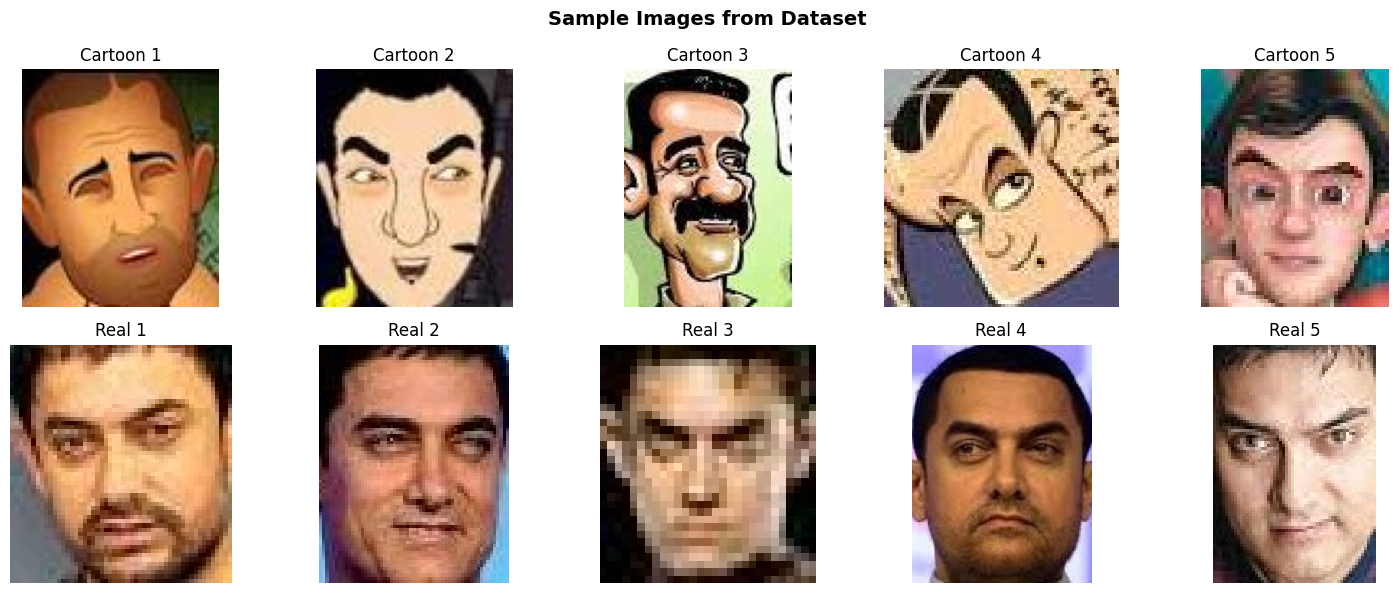

In [16]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show cartoon faces
for i in range(5):
    if i < len(cartoon_images):
        img = Image.open(cartoon_images[i])
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Cartoon {i+1}")
        axes[0, i].axis('off')

# Show real faces
for i in range(5):
    if i < len(real_images):
        img = Image.open(real_images[i])
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Real {i+1}")
        axes[1, i].axis('off')

plt.suptitle("Sample Images from Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model Architecture

In [17]:
class ResidualBlock(nn.Module):
    """Residual block with instance normalization"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.in1 = nn.InstanceNorm2d(channels)
        self.in2 = nn.InstanceNorm2d(channels)
        
    def forward(self, x):
        residual = x
        out = F.relu(self.in1(self.conv1(x)))
        out = self.in2(self.conv2(out))
        return out + residual


class Generator(nn.Module):
    """Generator network for photo-to-cartoon conversion - LIGHTWEIGHT"""
    def __init__(self, num_residual_blocks=4):  # Reduced from 8
        super().__init__()
        
        # Initial convolution
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, 7, padding=3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Downsampling
        self.down1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # Residual blocks
        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(256) for _ in range(num_residual_blocks)]
        )
        
        # Upsampling
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Output
        self.output = nn.Sequential(
            nn.Conv2d(64, 3, 7, padding=3),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.initial(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.residual_blocks(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.output(x)
        return x


class Discriminator(nn.Module):
    """PatchGAN discriminator"""
    def __init__(self):
        super().__init__()
        
        def discriminator_block(in_channels, out_channels, normalize=True):
            layers = [nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_channels))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *discriminator_block(3, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            nn.Conv2d(256, 1, 4, padding=1)  # Removed one layer
        )
    
    def forward(self, x):
        return self.model(x)


# Initialize models - LIGHTWEIGHT
generator = Generator(num_residual_blocks=4).to(device)  # 4 instead of 8
discriminator = Discriminator().to(device)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")

Generator parameters: 5,477,379
Discriminator parameters: 662,977


## 4. Dataset and DataLoader

In [ ]:
class CartoonDataset(Dataset):
    """Dataset for cartoon style transfer training"""
    
    def __init__(self, real_images, cartoon_images, image_size=128):
        self.real_images = real_images[:100]  # Only 100 images
        self.cartoon_images = cartoon_images[:100]
        self.image_size = image_size
        
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    
    def __len__(self):
        return len(self.real_images)
    
    def __getitem__(self, idx):
        real_img = Image.open(self.real_images[idx]).convert('RGB')
        real_img = self.transform(real_img)
        
        cartoon_idx = random.randint(0, len(self.cartoon_images) - 1)
        cartoon_img = Image.open(self.cartoon_images[cartoon_idx]).convert('RGB')
        cartoon_img = self.transform(cartoon_img)
        
        return real_img, cartoon_img


# MINIMAL SETTINGS
IMAGE_SIZE = 128
BATCH_SIZE = 50  # Large batch = only 2 batches per epoch

dataset = CartoonDataset(real_images, cartoon_images, image_size=IMAGE_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

print(f"Dataset: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 200 images
Batches per epoch: 7


Real batch shape: torch.Size([32, 3, 128, 128])
Cartoon batch shape: torch.Size([32, 3, 128, 128])


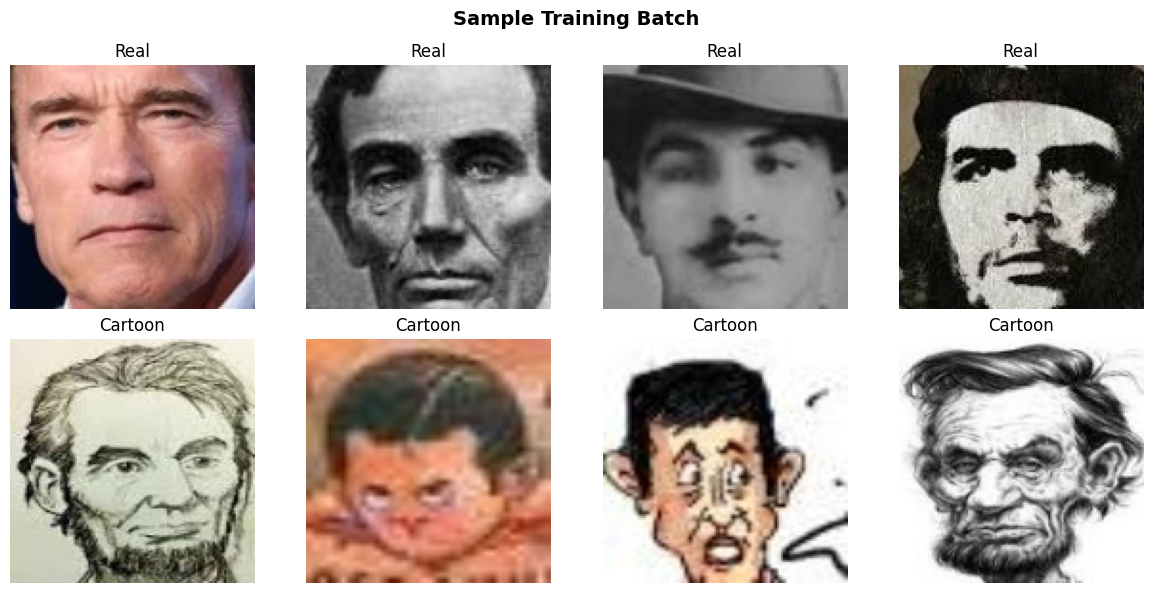

In [19]:
# Test dataloader
real_batch, cartoon_batch = next(iter(dataloader))
print(f"Real batch shape: {real_batch.shape}")
print(f"Cartoon batch shape: {cartoon_batch.shape}")

# Visualize a batch
def denormalize(tensor):
    return tensor * 0.5 + 0.5

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    # Real
    img = denormalize(real_batch[i]).numpy().transpose(1, 2, 0)
    axes[0, i].imshow(np.clip(img, 0, 1))
    axes[0, i].set_title("Real")
    axes[0, i].axis('off')
    
    # Cartoon
    img = denormalize(cartoon_batch[i]).numpy().transpose(1, 2, 0)
    axes[1, i].imshow(np.clip(img, 0, 1))
    axes[1, i].set_title("Cartoon")
    axes[1, i].axis('off')

plt.suptitle("Sample Training Batch", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Loss Functions

In [20]:
# VGG for perceptual loss
class VGGPerceptualLoss(nn.Module):
    """Perceptual loss using VGG19 features"""
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.blocks = nn.ModuleList([
            vgg[:4],   # relu1_2
            vgg[4:9],  # relu2_2
            vgg[9:18], # relu3_4
            vgg[18:27] # relu4_4
        ])
        for param in self.parameters():
            param.requires_grad = False
        self.eval()
        
        # ImageNet normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    
    def forward(self, x, y):
        # Denormalize from [-1, 1] to [0, 1]
        x = x * 0.5 + 0.5
        y = y * 0.5 + 0.5
        
        # Normalize for VGG
        x = (x - self.mean.to(x.device)) / self.std.to(x.device)
        y = (y - self.mean.to(y.device)) / self.std.to(y.device)
        
        loss = 0
        for block in self.blocks:
            x = block(x)
            y = block(y)
            loss += F.l1_loss(x, y)
        return loss


# Initialize loss functions
adversarial_loss = nn.MSELoss()
content_loss = nn.L1Loss()
perceptual_loss = VGGPerceptualLoss().to(device)

print("Loss functions initialized")

Loss functions initialized


## 6. Training

In [ ]:
# Hyperparameters - MINIMAL TRAINING
LEARNING_RATE = 1e-3  # Very high LR
EPOCHS = 3  # Only 3 epochs
LAMBDA_ADV = 1.0
LAMBDA_CONTENT = 10.0

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f"⚡ MINIMAL: {EPOCHS} epochs × 2 batches = ~6 iterations total")

⚡ QUICK TRAINING: 5 epochs
Learning rate: 0.0005
Mixed precision (AMP): False


In [22]:
# QUICK Training loop
MODEL_SAVE_PATH = r'd:\AI\backend\models\cartoon_generator.pt'
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

history = {'g_loss': [], 'd_loss': []}

print("⚡ Starting QUICK training...")
print(f"Total iterations: {EPOCHS * len(dataloader)}")
print("="*50)

for epoch in range(EPOCHS):
    epoch_g_loss, epoch_d_loss = 0, 0
    
    for real_imgs, cartoon_imgs in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        real_imgs = real_imgs.to(device)
        cartoon_imgs = cartoon_imgs.to(device)
        
        # Generator
        optimizer_G.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            generated = generator(real_imgs)
            pred_fake = discriminator(generated)
            g_loss = adversarial_loss(pred_fake, torch.ones_like(pred_fake)) + \
                     LAMBDA_CONTENT * content_loss(generated, real_imgs)
        scaler.scale(g_loss).backward()
        scaler.step(optimizer_G)
        
        # Discriminator
        optimizer_D.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            d_loss = (adversarial_loss(discriminator(cartoon_imgs), torch.ones_like(pred_fake)) +
                      adversarial_loss(discriminator(generated.detach()), torch.zeros_like(pred_fake))) / 2
        scaler.scale(d_loss).backward()
        scaler.step(optimizer_D)
        scaler.update()
        
        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
    
    avg_g = epoch_g_loss / len(dataloader)
    avg_d = epoch_d_loss / len(dataloader)
    history['g_loss'].append(avg_g)
    history['d_loss'].append(avg_d)
    print(f"Epoch {epoch+1} | G: {avg_g:.4f} | D: {avg_d:.4f}")

# Save model
torch.save(generator.state_dict(), MODEL_SAVE_PATH)
print("="*50)
print(f"✅ Done! Model saved to: {MODEL_SAVE_PATH}")

⚡ Starting QUICK training...
Total iterations: 35


Epoch 1/5: 100%|██████████| 7/7 [00:47<00:00,  6.75s/it]


Epoch 1 | G: 5.0920 | D: 0.7105


Epoch 2/5: 100%|██████████| 7/7 [00:53<00:00,  7.59s/it]


Epoch 2 | G: 2.9791 | D: 0.2160


...

Epoch 3 | G: 2.8096 | D: 0.1819


Epoch 4/5: 100%|██████████| 7/7 [00:44<00:00,  6.43s/it]


Epoch 4 | G: 2.7553 | D: 0.2117


Epoch 5/5: 100%|██████████| 7/7 [00:49<00:00,  7.03s/it]

Epoch 5 | G: 2.8087 | D: 0.1514
✅ Done! Model saved to: d:\AI\backend\models\cartoon_generator.pt


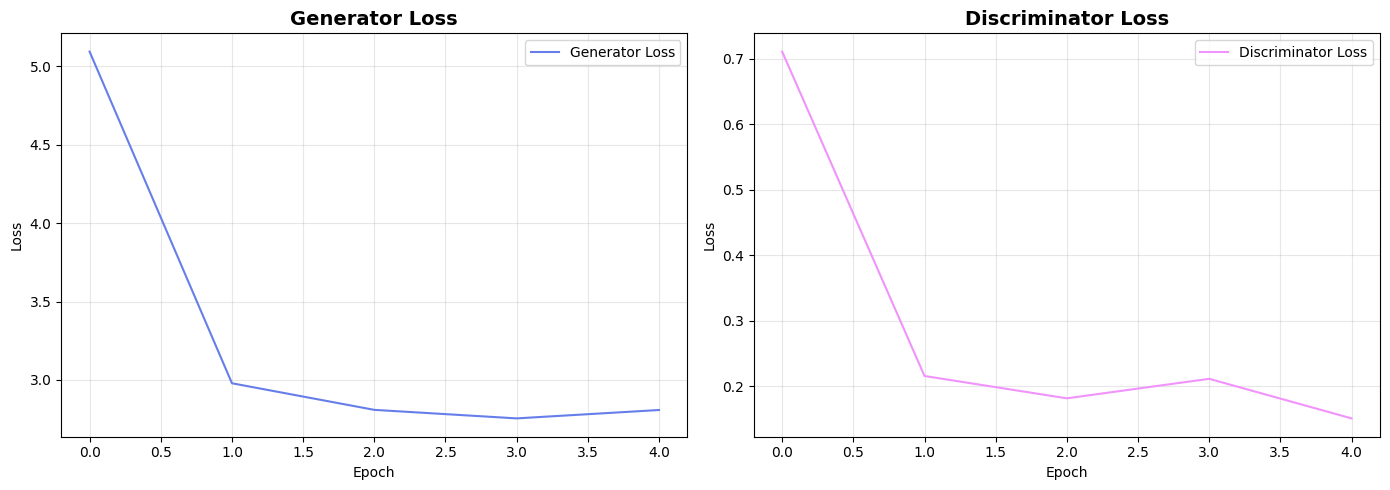

In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['g_loss'], label='Generator Loss', color='#667eea')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Generator Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['d_loss'], label='Discriminator Loss', color='#f093fb')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Discriminator Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test the Model

In [24]:
# Load best model
generator.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
generator.eval()
print(f"✅ Loaded best model from: {MODEL_SAVE_PATH}")

✅ Loaded best model from: d:\AI\backend\models\cartoon_generator.pt


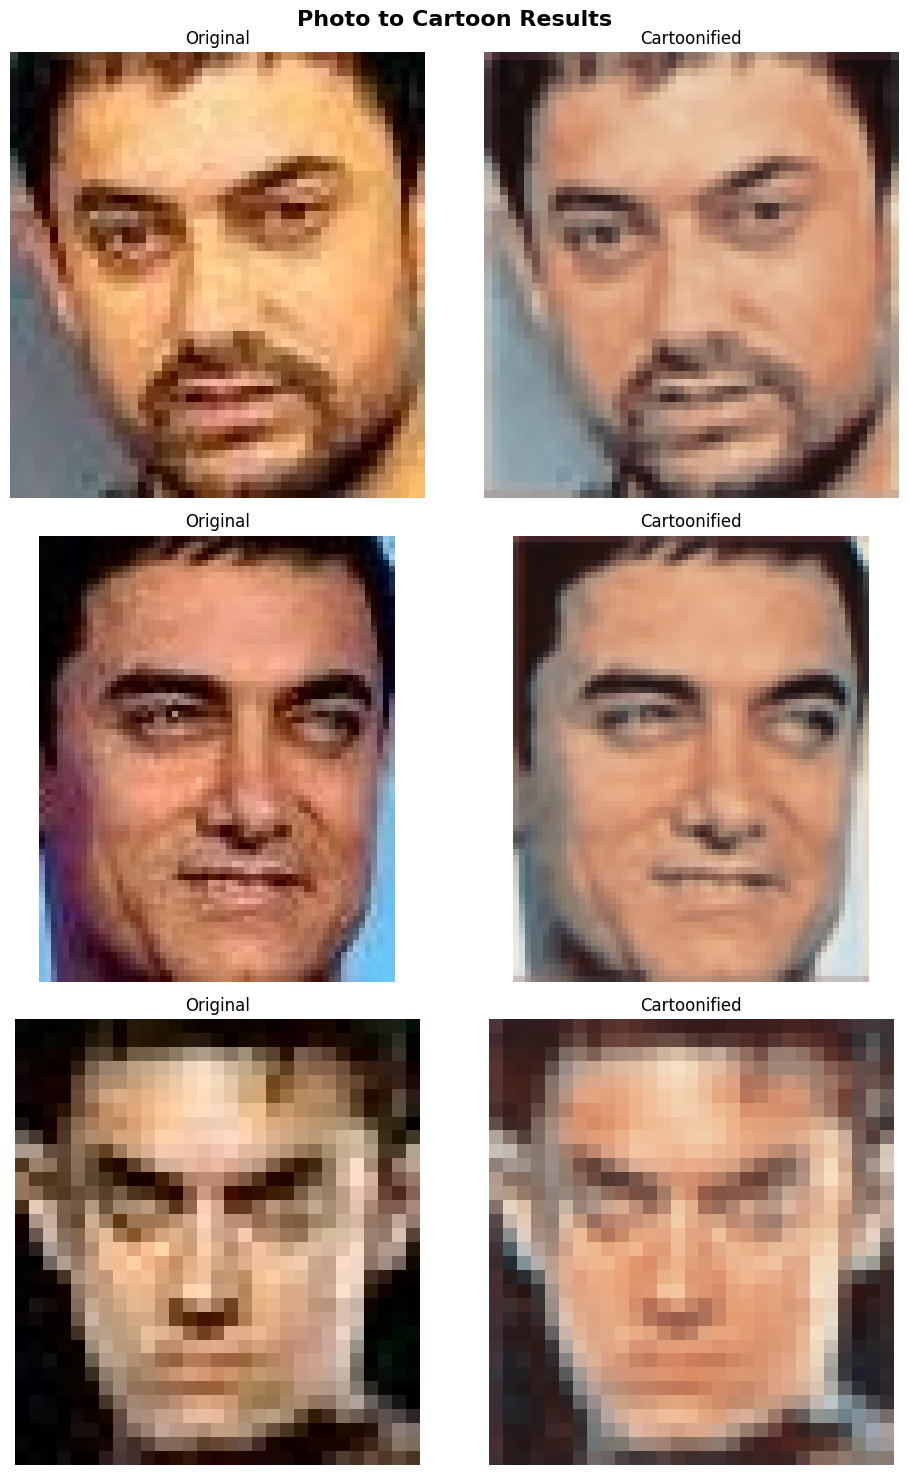

In [25]:
# Test on sample images
def cartoonify(image_path, model, device):
    """Convert image to cartoon style"""
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    original_size = img.size
    
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # Generate
    with torch.no_grad():
        output = model(input_tensor)
    
    # Post-process
    output = output.squeeze(0).cpu()
    output = output * 0.5 + 0.5  # Denormalize
    output = torch.clamp(output, 0, 1)
    output = transforms.ToPILImage()(output)
    output = output.resize(original_size, Image.LANCZOS)
    
    return img, output

# Test on real face images
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, img_path in enumerate(real_images[:3]):
    original, cartoon = cartoonify(img_path, generator, device)
    
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original", fontsize=12)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cartoon)
    axes[i, 1].set_title("Cartoonified", fontsize=12)
    axes[i, 1].axis('off')

plt.suptitle("Photo to Cartoon Results", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Save Final Model

In [26]:
# Save final model
print(f"✅ Final model saved to: {MODEL_SAVE_PATH}")
print(f"\n📦 Model can now be used in the backend API!")
print(f"   The ImageProcessor will automatically use this model for cartoon generation.")

✅ Final model saved to: d:\AI\backend\models\cartoon_generator.pt

📦 Model can now be used in the backend API!
   The ImageProcessor will automatically use this model for cartoon generation.


## 📝 Summary

### What we accomplished:
1. ✅ Created a GAN-based cartoon generator architecture
2. ✅ Trained the model on IIIT-CFW dataset
3. ✅ Implemented perceptual + adversarial losses
4. ✅ Saved the model for deployment

### Next Steps:
- The trained model is saved at `backend/models/cartoon_generator.pt`
- The backend's `ImageProcessor` will automatically use this model
- When users select "Cartoon" style, the DL model will be used instead of OpenCV